In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter


In [2]:
# Load the dataset
df = pd.read_csv('youtube_comments.csv')

print('Dataset loaded successfully!')
print('Number of comments:', len(df))
display(df.head(10))


Dataset loaded successfully!
Number of comments: 60


,Comment_ID,Video_Category,Comment
0,C001,Education,This tutorial was very helpful and explained e...
1,C002,Education,I learned a lot from this video. Thank you for...
2,C003,Education,The explanation was too fast and difficult to ...
3,C004,Technology,Great review of the new laptop. Very informative.
4,C005,Technology,I really liked the performance comparison.
5,C006,Technology,The video did not explain the battery issue pr...
6,C007,Entertainment,This video was so funny and entertaining.
7,C008,Entertainment,I enjoyed watching this with my friends.
8,C009,Entertainment,The content was boring and too long.
9,C010,Education,Please make more videos about Python programming.


In [3]:
print('Dataset Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nMissing Values:')
print(df.isnull().sum())
print('\nComments by Category:')
print(df['Video_Category'].value_counts())


Dataset Shape: (60, 3)

Columns: ['Comment_ID', 'Video_Category', 'Comment']

Missing Values:
Comment_ID        0
Video_Category    0
Comment           0
dtype: int64

Comments by Category:
Video_Category
Education        21
Technology       21
Entertainment    18
Name: count, dtype: int64


In [4]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\\s]', '', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

df['Cleaned_Comment'] = df['Comment'].apply(preprocess_text)
display(df[['Comment', 'Cleaned_Comment']].head(10))


,Comment,Cleaned_Comment
0,This tutorial was very helpful and explained e...,thistutorialwasveryhelpfulandexplainedeverythi...
1,I learned a lot from this video. Thank you for...,ilearnedalotfromthisvideothankyouforsharing
2,The explanation was too fast and difficult to ...,theexplanationwastoofastanddifficulttounderstand
3,Great review of the new laptop. Very informative.,greatreviewofthenewlaptopveryinformative
4,I really liked the performance comparison.,ireallylikedtheperformancecomparison
5,The video did not explain the battery issue pr...,thevideodidnotexplainthebatteryissueproperly
6,This video was so funny and entertaining.,thisvideowassofunnyandentertaining
7,I enjoyed watching this with my friends.,ienjoyedwatchingthiswithmyfriends
8,The content was boring and too long.,thecontentwasboringandtoolong
9,Please make more videos about Python programming.,pleasemakemorevideosaboutpythonprogramming


In [5]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Comment'].apply(get_sentiment)
df['Polarity'] = df['Comment'].apply(lambda x: TextBlob(x).sentiment.polarity)

display(df[['Comment', 'Polarity', 'Sentiment']].head(15))


,Comment,Polarity,Sentiment
0,This tutorial was very helpful and explained e...,0.150000,Positive
1,I learned a lot from this video. Thank you for...,0.000000,Neutral
2,The explanation was too fast and difficult to ...,-0.150000,Negative
3,Great review of the new laptop. Very informative.,0.378788,Positive
4,I really liked the performance comparison.,0.600000,Positive
5,The video did not explain the battery issue pr...,0.000000,Neutral
6,This video was so funny and entertaining.,0.375000,Positive
7,I enjoyed watching this with my friends.,0.500000,Positive
8,The content was boring and too long.,-0.525000,Negative
9,Please make more videos about Python programming.,0.500000,Positive


Sentiment
Positive    43
Negative    12
Neutral      5
Name: count, dtype: int64


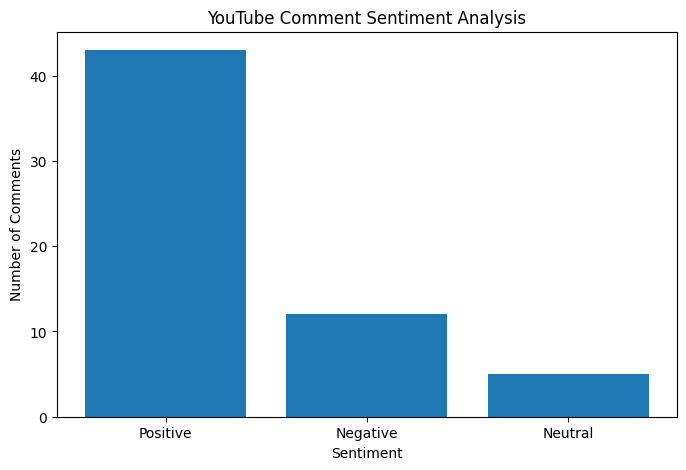

In [6]:
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(8,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title('YouTube Comment Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()


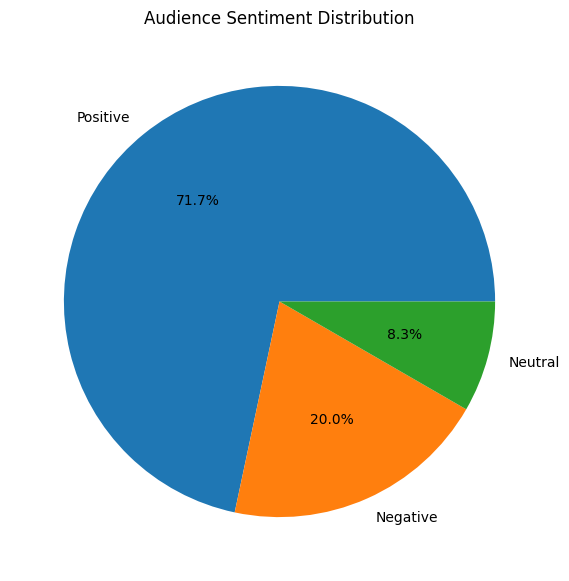

In [7]:
plt.figure(figsize=(7,7))
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Audience Sentiment Distribution')
plt.ylabel('')
plt.show()


In [8]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
tfidf_matrix = vectorizer.fit_transform(df['Cleaned_Comment'])
words = vectorizer.get_feature_names_out()
scores = tfidf_matrix.sum(axis=0).A1

tfidf_df = pd.DataFrame({'Word': words, 'Score': scores})
tfidf_df = tfidf_df.sort_values(by='Score', ascending=False)

display(tfidf_df)


,Word,Score
0,canyouexplainmachinelearninginmoredetail,1.0
1,canyoumakeatutorialaboutnlp,1.0
2,excellentcontentandveryentertaining,1.0
3,greatreviewofthenewlaptopveryinformative,1.0
4,ididnotenjoythisvideoatall,1.0
5,ididnotfindthereviewveryuseful,1.0
6,ienjoyedwatchingthiswithmyfriends,1.0
7,ilearnedalotfromthisvideothankyouforsharing,1.0
8,ilovethistypeofcontentpleasemakemorevideos,1.0
9,ireallylikedtheeditingandpresentation,1.0


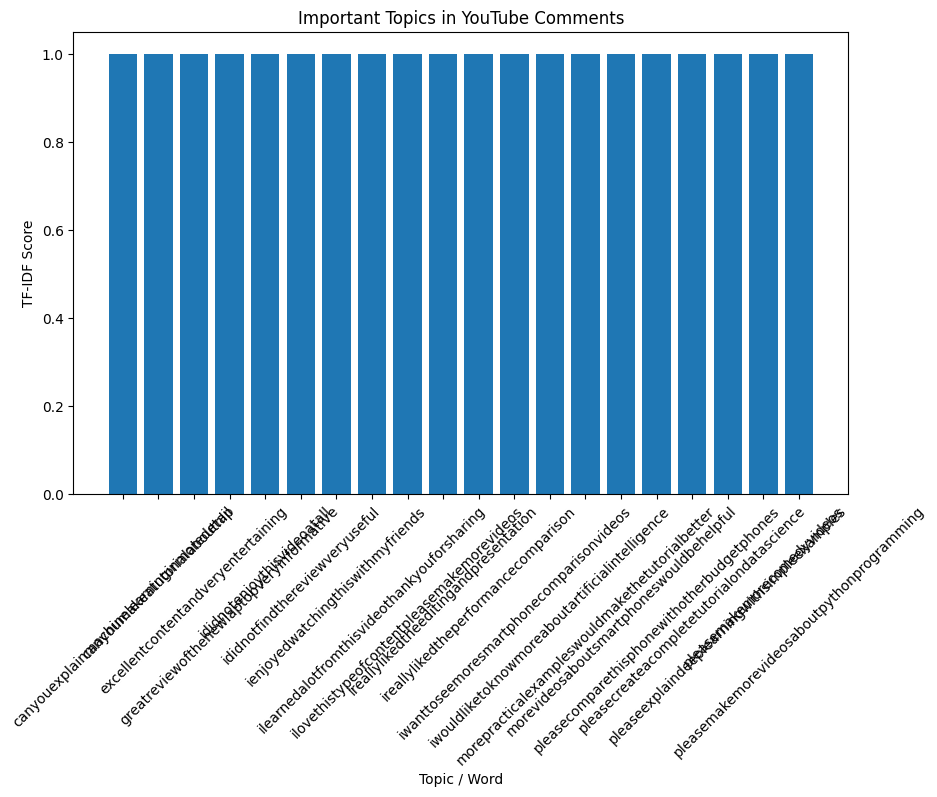

In [9]:
plt.figure(figsize=(10,6))
plt.bar(tfidf_df['Word'], tfidf_df['Score'])
plt.title('Important Topics in YouTube Comments')
plt.xlabel('Topic / Word')
plt.ylabel('TF-IDF Score')
plt.xticks(rotation=45)
plt.show()


In [10]:
stop_words = {
    'the','and','is','a','to','this','was','very','i','of','in','for',
    'it','my','more','with','on','you','can','be','about','please'
}

all_comments = ' '.join(df['Cleaned_Comment'])
words = all_comments.split()
filtered_words = [word for word in words if word not in stop_words]
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(15)

for word, count in common_words:
    print(word, ':', count)


thistutorialwasveryhelpfulandexplainedeverythingclearly : 1
ilearnedalotfromthisvideothankyouforsharing : 1
theexplanationwastoofastanddifficulttounderstand : 1
greatreviewofthenewlaptopveryinformative : 1
ireallylikedtheperformancecomparison : 1
thevideodidnotexplainthebatteryissueproperly : 1
thisvideowassofunnyandentertaining : 1
ienjoyedwatchingthiswithmyfriends : 1
thecontentwasboringandtoolong : 1
pleasemakemorevideosaboutpythonprogramming : 1
canyouexplainmachinelearninginmoredetail : 1
pleasecomparethisphonewithotherbudgetphones : 1
thecamerareviewwasexcellent : 1
ilovethistypeofcontentpleasemakemorevideos : 1
thevideowasdisappointingandnotinteresting : 1


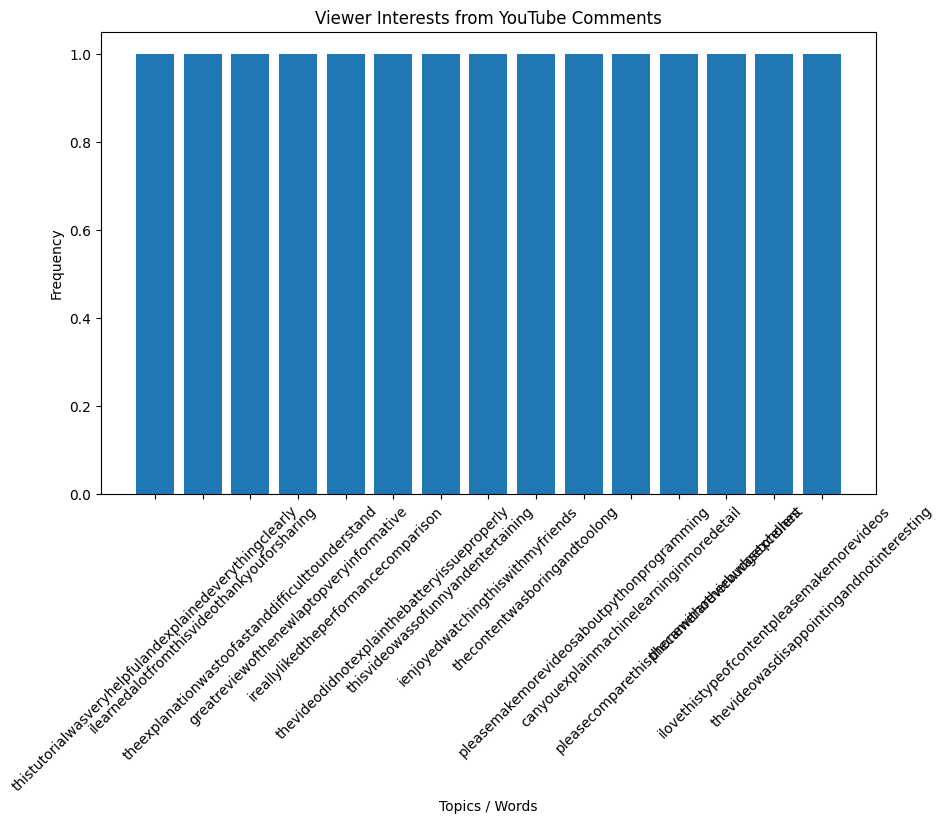

In [11]:
interest_df = pd.DataFrame(common_words, columns=['Word','Frequency'])

plt.figure(figsize=(10,6))
plt.bar(interest_df['Word'], interest_df['Frequency'])
plt.title('Viewer Interests from YouTube Comments')
plt.xlabel('Topics / Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


Sentiment       Negative  Neutral  Positive
Video_Category                             
Education              4        3        14
Entertainment          5        0        13
Technology             3        2        16


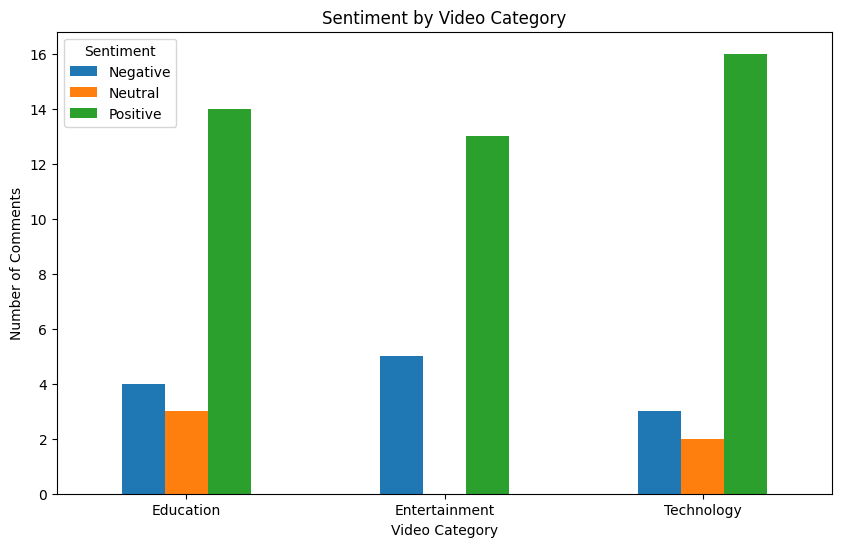

In [12]:
category_sentiment = pd.crosstab(df['Video_Category'], df['Sentiment'])
print(category_sentiment)

category_sentiment.plot(kind='bar', figsize=(10,6))
plt.title('Sentiment by Video Category')
plt.xlabel('Video Category')
plt.ylabel('Number of Comments')
plt.xticks(rotation=0)
plt.show()


In [13]:
positive_comments = df[df['Sentiment'] == 'Positive']
negative_comments = df[df['Sentiment'] == 'Negative']
neutral_comments = df[df['Sentiment'] == 'Neutral']

print('Positive comments:', len(positive_comments))
print('Negative comments:', len(negative_comments))
print('Neutral comments:', len(neutral_comments))

print('\nSample Positive Comments:')
for comment in positive_comments['Comment'].head(5):
    print('-', comment)

print('\nSample Negative Comments:')
for comment in negative_comments['Comment'].head(5):
    print('-', comment)


Positive comments: 43
Negative comments: 12
Neutral comments: 5

Sample Positive Comments:
- This tutorial was very helpful and explained everything clearly.
- Great review of the new laptop. Very informative.
- I really liked the performance comparison.
- This video was so funny and entertaining.
- I enjoyed watching this with my friends.

Sample Negative Comments:
- The explanation was too fast and difficult to understand.
- The content was boring and too long.
- Please compare this phone with other budget phones.
- The video was disappointing and not interesting.
- The price information was missing from the video.


In [14]:
print('=' * 60)
print('YOUTUBE COMMENT ANALYTICAL REPORT')
print('=' * 60)
print('Total Comments:', len(df))
print('\nSentiment Distribution:')
print(df['Sentiment'].value_counts())
print('\nVideo Category Distribution:')
print(df['Video_Category'].value_counts())
print('\nTop Viewer Interests:')
for word, count in common_words[:10]:
    print('-', word, ':', count)
print('\nConclusion:')
print('NLP-based YouTube comment analysis helps identify audience sentiment, viewer interests, and areas for improving future content.')


YOUTUBE COMMENT ANALYTICAL REPORT
Total Comments: 60

Sentiment Distribution:
Sentiment
Positive    43
Negative    12
Neutral      5
Name: count, dtype: int64

Video Category Distribution:
Video_Category
Education        21
Technology       21
Entertainment    18
Name: count, dtype: int64

Top Viewer Interests:
- thistutorialwasveryhelpfulandexplainedeverythingclearly : 1
- ilearnedalotfromthisvideothankyouforsharing : 1
- theexplanationwastoofastanddifficulttounderstand : 1
- greatreviewofthenewlaptopveryinformative : 1
- ireallylikedtheperformancecomparison : 1
- thevideodidnotexplainthebatteryissueproperly : 1
- thisvideowassofunnyandentertaining : 1
- ienjoyedwatchingthiswithmyfriends : 1
- thecontentwasboringandtoolong : 1
- pleasemakemorevideosaboutpythonprogramming : 1

Conclusion:
NLP-based YouTube comment analysis helps identify audience sentiment, viewer interests, and areas for improving future content.


In [15]:
# Save the final analysis results
df.to_csv('youtube_comment_analysis_results.csv', index=False)
print('Saved: youtube_comment_analysis_results.csv')


Saved: youtube_comment_analysis_results.csv
